# Регуляризация

Если созданная чрезмерно сложная модель идеально подходит под тренировочные данные, но полностью терпит крах на реальных (новых, тестовых) данных, то это значит, что мы столкнулись с **переобучением**.

**Регуляризация** - это одна из техник, используемых для предотвращения переобучения модели на обучающих данных. Смысл регуляризации заключается во введении ограничений или штрафов на сложность модели.

Основная цель регуляризации — создать более устойчивую модель, которая лучше обобщает закономерности и уменьшает риск переобучения, сохраняя при этом адекватный уровень точности.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_context("paper", font_scale=1.2)

Сгенерируем данные (10 объектов), подчиняющиеся зависимости 3-го порядка. Добавим к ним шум.

In [3]:
def f(x):
    return 5.5 + 10.0 * x - 7.7 * x ** 2 + 3.3 * x ** 3

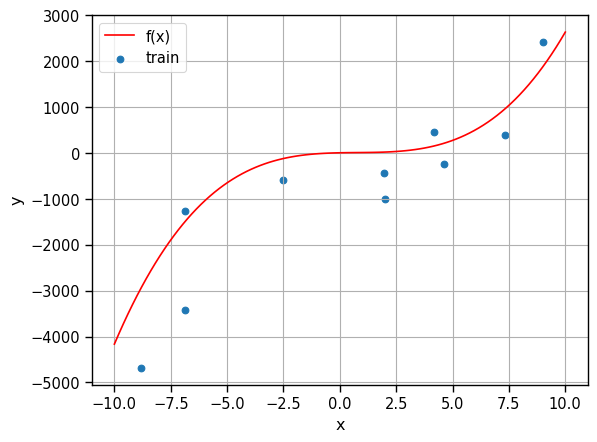

In [4]:
np.random.seed(42)
x = np.linspace(start=-10, stop=10, num=100)
plt.plot(x, f(x), 'r', label='f(x)')

x_train = np.random.uniform(low=-10, high=10, size=10)
y_train = f(x_train) + 1000 * np.random.randn(10)
plt.scatter(x_train, y_train, label='train')
plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.legend();

Построим модель, используя многочлен 7-й степени.

In [5]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

poly = PolynomialFeatures(degree=7)
x_train_poly = poly.fit_transform(x_train.reshape(-1, 1))
x_poly = poly.fit_transform(x.reshape(-1, 1))

reg = LinearRegression(fit_intercept=False)
reg.fit(x_train_poly, y_train)

LinearRegression(fit_intercept=False)

In [6]:
y_true = f(x) # исходная функция
y_pred = reg.predict(x_poly) # прогнозы
print(f'R2 на исходной функции = {r2_score(y_true,  y_pred):.3}')
y_train_pred = reg.predict(x_train_poly)
print(f'R2 на обучающих данных = {r2_score(y_train, y_train_pred):.3}')

R2 на исходной функции = -66.5
R2 на обучающих данных = 0.93


Одним из признаков переобучения в линейных моделях является получение больших по модулю весов.

In [7]:
reg.coef_

array([-5.33517849e+03,  1.34377044e+03,  1.00648329e+03, -2.25783737e+02,
       -3.10418219e+01,  6.49102882e+00,  2.42096782e-01, -4.79740378e-02])

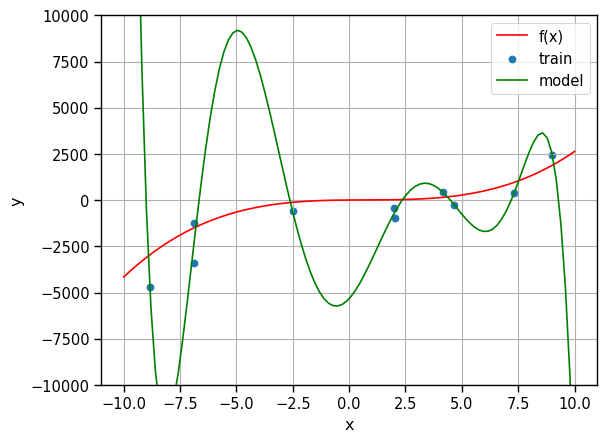

In [8]:
plt.plot(x, f(x), 'r', label='f(x)')
plt.scatter(x_train, y_train, label='train')
plt.plot(x, y_pred, color='g', label='model')
plt.ylim(-10000, 10000)
plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.legend();

Наблюдаем **переобучение**. Алгоритм слишком сильно подогнан под обучающую выборку, и за счет этого будет давать неадекватные ответы на новых точках. Для борьбы с переобучением будем использовать **регуляризацию**.


Метод регуляризации заключается в "штрафовании" модели за слишком большие веса путем добавления нового слагаемого к функции потерь:

$$\sum^{n}_{i=1}L_i({x}_i,{w}) + \alpha \sum^{m}_{j=1}|w_{j}| \rightarrow \underset{w}{\text{min}}$$

или

$$\sum^{n}_{i=1}L_i({x}_i,{w}) + \alpha \sum^{m}_{j=1}w_{j}^{2} \rightarrow \underset{w}{\text{min}}$$

В первом случае речь идет о **$L_1$-регуляризации**, а во втором - **$L_2$-регуляризации**.

L1 регуляризация добавляет к функции потерь модели штраф, равный сумме абсолютных значений коэффициентов (весов) модели. В L2 регуляризации к функции потерь добавляется штраф, пропорциональный квадрату величины весов модели.

Коэффицент $\alpha$ - коэффициент регуляризации. Чем больше его значение, тем больше штраф и модель будет получаться более простая (веса будут меньше). При слишком низких его значениях появляется вероятность усложнения модели и переобучения.

Выбор оптимального значения этого коэфициента является отдельной задачей и заключается в многократном обучении модели с разными его значениями и сравнении их качества.

$L_{1}$-регуляризация также называется **Lasso**, $L_{2}$-регуляризация - **Ridge**. По этим именам регуляризаторы можно найти в модуле `sklearn.linear_models`.

## Модель регрессии Lasso из библиотеки sklearn

In [9]:
from sklearn.linear_model import Lasso

Lasso().get_params()

{'alpha': 1.0,
 'copy_X': True,
 'fit_intercept': True,
 'max_iter': 1000,
 'positive': False,
 'precompute': False,
 'random_state': None,
 'selection': 'cyclic',
 'tol': 0.0001,
 'warm_start': False}

Параметр `alpha` задает силу регуляризации. Он должен быть неотрицательным вещественным числом, т. е. в диапазоне [0, inf).

Когда `alpha` = 0, регуляризации нет, алгоритм находит веса по методу наименьших квадратов.

In [10]:
reg = Lasso(alpha=1,
            fit_intercept=False,
            tol=1e-1,
            max_iter=10000
            )
reg.fit(x_train_poly, y_train)

y_pred = reg.predict(x_poly) # прогнозы
print(f'R2 на исходной функции = {r2_score(y_true,  y_pred):.3}')
y_train_pred = reg.predict(x_train_poly)
print(f'R2 на обучающих данных = {r2_score(y_train, y_train_pred):.3}')

R2 на исходной функции = 0.439
R2 на обучающих данных = 0.852


In [11]:
reg.coef_

array([-8.19663065e+02,  2.21455686e+02, -2.91186551e+00,  9.93334089e-01,
       -7.91095784e-03,  7.12368775e-03, -1.34346603e-04,  5.98723795e-05])

Посмотрим, как меняются веса при изменении коэффициента регуляризации.

In [12]:
alpha_list = np.logspace(base=10.0, start=-2, stop=3, num=16)
alpha_list

array([1.00000000e-02, 2.15443469e-02, 4.64158883e-02, 1.00000000e-01,
       2.15443469e-01, 4.64158883e-01, 1.00000000e+00, 2.15443469e+00,
       4.64158883e+00, 1.00000000e+01, 2.15443469e+01, 4.64158883e+01,
       1.00000000e+02, 2.15443469e+02, 4.64158883e+02, 1.00000000e+03])

In [13]:
w_list = []
for alpha in alpha_list:
    reg = Lasso(alpha=alpha, fit_intercept=False, tol=0.1, max_iter=10000)
    reg.fit(x_train_poly, y_train)
    w_list.append(reg.coef_)

w_list = np.array(w_list)

In [14]:
w_list[0, :]

array([-8.21203233e+02,  2.21535569e+02, -2.88331009e+00,  9.92102610e-01,
       -7.97211418e-03,  7.12384264e-03, -1.34708050e-04,  5.98859086e-05])

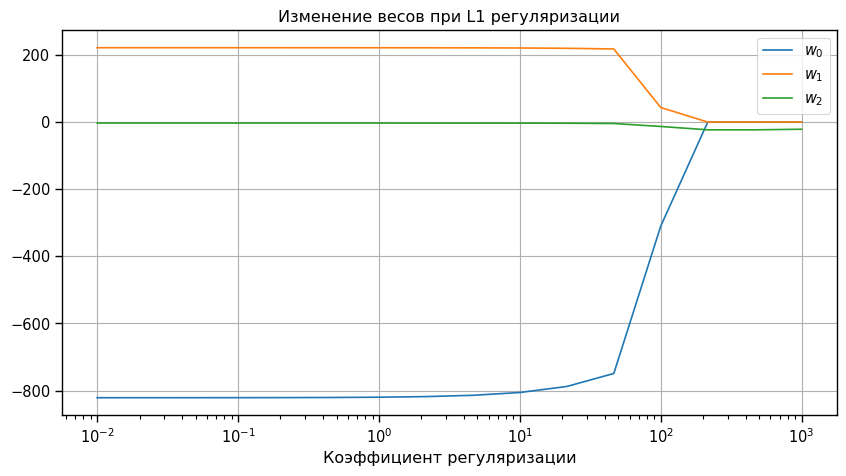

In [15]:
# Визуализируем изменение весов при L1 регуляризации
plt.figure(figsize=(10, 5))
plt.title('Изменение весов при L1 регуляризации')
plt.xscale('log')
for j in range(3):
    plt.plot(alpha_list, w_list[:, j], label=f'$w_{j}$')
plt.xlabel('Коэффициент регуляризации')
plt.grid()
plt.legend();

In [16]:
reg.coef_

array([-0.00000000e+00, -0.00000000e+00, -2.13192031e+01,  3.70955173e+00,
        3.55316006e-02,  1.00173860e-02,  3.15611045e-04,  7.29505414e-05])

L1 может привести к тому, что некоторые веса станут равными нулю. Это означает, что L1 регуляризация может полностью исключить некоторые признаки из модели. Это полезно в ситуациях, где признаков много, но только некоторые из них важны для прогнозирования.

Проверим точность модели при большом значении коэффициента регуляризации (когда полученные моделью веса очень маленькие).

In [17]:
reg = Lasso(alpha=1e3,
            fit_intercept=False,
            tol=1e-1,
            max_iter=10000)
reg.fit(x_train_poly, y_train)

y_pred = reg.predict(x_poly) # прогнозы
print(f'R2 на исходной функции = {r2_score(y_true,  y_pred):.3}')
y_train_pred = reg.predict(x_train_poly)
print(f'R2 на обучающих данных = {r2_score(y_train, y_train_pred):.3}')

R2 на исходной функции = 0.688
R2 на обучающих данных = 0.89


## Модель регрессии Ridge из библиотеки sklearn

In [18]:
from sklearn.linear_model import Ridge

Ridge().get_params()

{'alpha': 1.0,
 'copy_X': True,
 'fit_intercept': True,
 'max_iter': None,
 'positive': False,
 'random_state': None,
 'solver': 'auto',
 'tol': 0.0001}

In [19]:
reg = Ridge(alpha=0.1,
            fit_intercept=False)

reg.fit(x_train_poly, y_train)

y_pred = reg.predict(x_poly)
print(f'R2 на исходной функции = {r2_score(y_true,  y_pred):.3}')
y_train_pred = reg.predict(x_train_poly)
print(f'R2 на обучающих данных = {r2_score(y_train, y_train_pred):.3}')

R2 на исходной функции = 0.202
R2 на обучающих данных = 0.921


In [20]:
reg.coef_

array([-7.26770114e+02, -7.53807243e+01,  3.68492942e+01,  1.56795784e+01,
       -1.39746457e+00, -3.39724280e-01,  1.04963850e-02,  2.72440489e-03])

In [21]:
w_list = []
for alpha in alpha_list:
    reg = Ridge(alpha=alpha, fit_intercept=False, tol=0.1, max_iter=10000)
    reg.fit(x_train_poly, y_train)
    w_list.append(reg.coef_)

w_list = np.array(w_list)

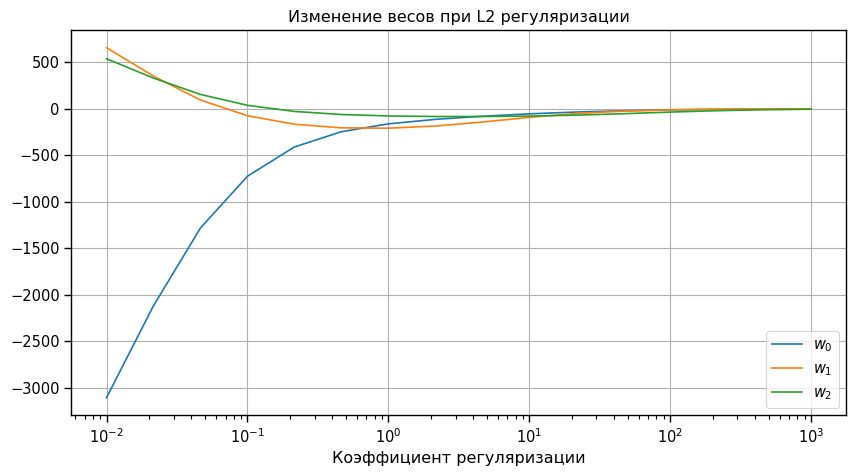

In [22]:
# Визуализируем изменение весов при L2 регуляризации
plt.figure(figsize=(10, 5))
plt.title('Изменение весов при L2 регуляризации')
plt.xscale('log')
for j in range(3):
    plt.plot(alpha_list, w_list[:, j], label=f'$w_{j}$')
plt.xlabel('Коэффициент регуляризации')
plt.grid()
plt.legend();

In [23]:
reg.coef_

array([-1.65144017e+00, -8.62283071e-01, -5.30953646e+00,  3.63673117e+00,
       -6.93528321e-01, -8.15603830e-03,  7.00961675e-03,  3.12169137e-04])

Путём уменьшения величины весов, L2 регуляризация  делает модель менее чувствительной к отдельным точкам данных, и таким образом уменьшает риск переобучения.

В отличие от L1 регуляризации, L2 не склонна обнулять веса. Вместо этого она уменьшает веса постепенно, делая модель более "гладкой" и менее подверженной влиянию шума в данных.

L2 регуляризация полезна в ситуациях, когда количество признаков в данных велико или когда они сильно коррелированы. Она сохраняет все признаки, уменьшая их влияние.

In [24]:
reg = Ridge(alpha=1e3,
            fit_intercept=False)

reg.fit(x_train_poly, y_train)

y_pred = reg.predict(x_poly)
print(f'R2 на исходной функции = {r2_score(y_true,  y_pred):.3}')
y_train_pred = reg.predict(x_train_poly)
print(f'R2 на обучающих данных = {r2_score(y_train, y_train_pred):.3}')

R2 на исходной функции = 0.639
R2 на обучающих данных = 0.89


## Регуляризация в модели SGD линейной регрессии (Stochastic Gradient Descent - стохастический градиентный спуск) из библиотеки sklearn

In [25]:
from sklearn.linear_model import SGDRegressor

SGDRegressor().get_params()

{'alpha': 0.0001,
 'average': False,
 'early_stopping': False,
 'epsilon': 0.1,
 'eta0': 0.01,
 'fit_intercept': True,
 'l1_ratio': 0.15,
 'learning_rate': 'invscaling',
 'loss': 'squared_error',
 'max_iter': 1000,
 'n_iter_no_change': 5,
 'penalty': 'l2',
 'power_t': 0.25,
 'random_state': None,
 'shuffle': True,
 'tol': 0.001,
 'validation_fraction': 0.1,
 'verbose': 0,
 'warm_start': False}

Модель может использовать сразу два регуляризатора L1 и L2. Такая модель регрессии называется **Еlastic net**. В пакете sklearn существует класс `ElasticNet`. Но мы посмотрим, как добавить этот тип регуляризации к стохастическому градиентному спуску.

### Параметры SGDRegressor, отвечающие за регуляризацию:

* **penalty**: {‘l2’, ‘l1’, ‘elasticnet’} – тип регуляризации (default=’l2’)
* **alpha** – коэффициент регуляризации (default=0.0001)
* **l1_ratio** - параметр Elastic Net регуляризации. l1_ratio=0 соответствует L2 регуляризации, l1_ratio=1 - L1 (default=0.15)

Не забываем, что линейная регрессия с градиентым спуском требует масштабирования данных перед обучением.

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_st = scaler.fit_transform(x_poly)
x_train_st = scaler.fit_transform(x_train_poly)

In [27]:
reg = SGDRegressor(alpha=1, penalty='elasticnet',
                   l1_ratio=0.25,
                   fit_intercept=False)

reg.fit(x_train_st, y_train)

y_pred = reg.predict(x_st)
print(f'R2 на исходной функции = {r2_score(y_true,  y_pred):.3}')
y_train_pred = reg.predict(x_train_st)
print(f'R2 на обучающих данных = {r2_score(y_train, y_train_pred):.3}')

R2 на исходной функции = 0.941
R2 на обучающих данных = 0.689


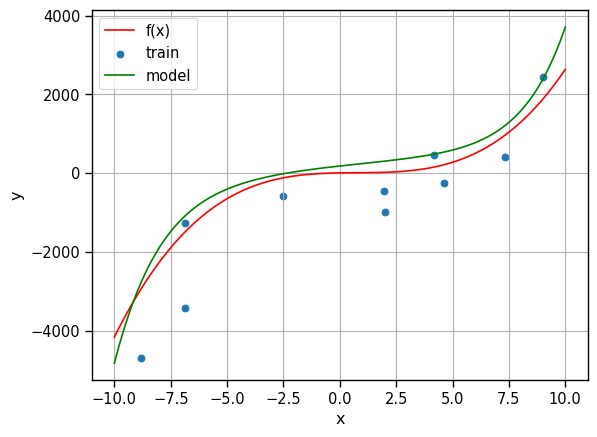

In [28]:
plt.plot(x, f(x), 'r', label='f(x)')
plt.scatter(x_train, y_train, label='train')
plt.plot(x, y_pred, color='g', label='model')
plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.legend();

# Документация

[PolynomialFeatures](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html)

[Lasso](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html)

[Ridge](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html)

[ElasticNet](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNet.html?highlight=elastic+net#sklearn.linear_model.ElasticNet)


# Задания

1. Сгенерировать данные для задачи регресии, разбить их на обучающую и тестовую выборки, обучить полиномиальную регрессию (выбрать большую степень, чтобы наблюдалось переобучение) и сравнить влияние коэффициентов регуляризации L1 и L2 на величину весов (графически). (4 балла)

2. Подобрать оптимальные коэффициенты регуляризации и получить максимальную точность модели на тестовых данных. (3 балла)

3. Сделать вывод. (1 балл)

In [29]:
from sklearn.datasets import make_regression

X, y, coef = make_regression(n_samples=1000,
                             n_features=2,
                             n_informative=2,
                             n_targets=1,
                             noise=10,
                             bias=0, # intersept=0
                             coef=True,
                             random_state=42)
coef

array([40.71064891,  6.60098441])

In [30]:
from sklearn.model_selection import train_test_split

# делим данные на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3,
                                                    random_state=42)